In [1]:
# ==========================================
# TYPING
# ==========================================

from typing import TypedDict, List, Annotated, Sequence, Literal


# ==========================================
# LANGCHAIN HUB
# ==========================================

import langchainhub as hub


# ==========================================
# CORE MESSAGES
# ==========================================

from langchain_core.messages import (
    BaseMessage,
    HumanMessage
)


# ==========================================
# OUTPUT PARSER
# ==========================================

from langchain_core.output_parsers import StrOutputParser


# ==========================================
# PROMPTS
# ==========================================

from langchain_core.prompts import PromptTemplate


# ==========================================
# PYDANTIC
# ==========================================

from pydantic import BaseModel, Field


# ==========================================
# LANGGRAPH MESSAGE STATE
# ==========================================

from langgraph.graph.message import add_messages


# ==========================================
# LANGGRAPH GRAPH
# ==========================================

from langgraph.graph import (
    StateGraph,
    START,
    END
)


# ==========================================
# LANGGRAPH PREBUILT
# ==========================================

from langgraph.prebuilt import (
    ToolNode,
    tools_condition,

)


# ==========================================
# DOCUMENT LOADERS
# ==========================================

from langchain_community.document_loaders import (
    WebBaseLoader,
    PyMuPDFLoader
)


# ==========================================
# VECTOR STORE
# ==========================================

from langchain_community.vectorstores import Chroma


# ==========================================
# TEXT SPLITTER
# ==========================================

from langchain_text_splitters import (
    RecursiveCharacterTextSplitter
)


# ==========================================
# RETRIEVER TOOL
# ==========================================

from langchain_core.tools import create_retriever_tool


# ==========================================
# WEB SEARCH TOOL
# ==========================================

from langchain_community.tools import DuckDuckGoSearchRun


# ==========================================
# EMBEDDINGS
# ==========================================

from langchain_huggingface import HuggingFaceEmbeddings


# ==========================================
# LLM
# ==========================================

from langchain_groq import ChatGroq


# ==========================================
# DOCUMENT TYPE
# ==========================================

from langchain_core.documents import Document

c:\Users\rajku\OneDrive\Desktop\youtube_live_langraph_avneet\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
import langchain
import importlib.metadata

print("LangChain Version:", langchain.__version__)
print("LangGraph Version:", importlib.metadata.version("langgraph"))

LangChain Version: 1.3.0
LangGraph Version: 1.2.0


In [3]:
from langgraph.graph import StateGraph


In [4]:
!pip install sentence-transformers


In [5]:
from langchain_huggingface import HuggingFaceEmbeddings # load embeddings
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-V2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7171.89it/s]


In [6]:
from langchain_groq import ChatGroq

In [7]:
# then needed embedding model and llm
# making object for the model
llm=ChatGroq(model_name="llama-3.3-70b-versatile")

In [8]:
llm.invoke("hi hello world")

AIMessage(content="Hello. It's nice to meet you. Is there something I can help you with, or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 38, 'total_tokens': 64, 'completion_time': 0.067845581, 'completion_tokens_details': None, 'prompt_time': 0.009121746, 'prompt_tokens_details': None, 'queue_time': 0.281340801, 'total_time': 0.076967327}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e3b2e-14bd-7c72-b733-a1eac9a31ae3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 38, 'output_tokens': 26, 'total_tokens': 64})

In [9]:
from langchain_community.document_loaders import PyMuPDFLoader # load the data  

def load_pdf(filepath):

    loader = PyMuPDFLoader(filepath) # load the pdf file

    documents = loader.load()

    # optional cleanup
    for doc in documents:
        doc.page_content = (
            doc.page_content
            .replace("\n", " ")
            .replace("\t", " ")
            .strip()
        )

    return documents # loading pdf file path

In [10]:
# to see first 500 char 
pdf_text = load_pdf("Avneet_Kaur_Research_Document.pdf")
print(pdf_text[:500])   # preview first 500 characters

[Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-05-15T18:22:15+00:00', 'source': 'Avneet_Kaur_Research_Document.pdf', 'file_path': 'Avneet_Kaur_Research_Document.pdf', 'total_pages': 22, 'format': 'PDF 1.4', 'title': 'Avneet Kaur – A Comprehensive Research Document', 'author': 'Research Desk', 'subject': 'Indian Entertainment Industry Profile', 'keywords': '', 'moddate': '2026-05-15T18:22:15+00:00', 'trapped': '', 'modDate': "D:20260515182215+00'00'", 'creationDate': "D:20260515182215+00'00'", 'page': 0}, page_content='AVNEET KAUR  |  A Comprehensive Research Document © Research Desk  2026 Page 1 AVNEET KAUR A Comprehensive Research Document From Dance Reality Shows to International Cinema Actress · Dancer · Social Media Influencer Career Span: 2010 – Present | Base: Mumbai, India Prepared: May 2026 15-Page Research Overview | Audience: General Readers'), Document(metadata={'producer': 'ReportLab PDF Library - (o

In [11]:
pdf_text # to see inside the  pdf

[Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-05-15T18:22:15+00:00', 'source': 'Avneet_Kaur_Research_Document.pdf', 'file_path': 'Avneet_Kaur_Research_Document.pdf', 'total_pages': 22, 'format': 'PDF 1.4', 'title': 'Avneet Kaur – A Comprehensive Research Document', 'author': 'Research Desk', 'subject': 'Indian Entertainment Industry Profile', 'keywords': '', 'moddate': '2026-05-15T18:22:15+00:00', 'trapped': '', 'modDate': "D:20260515182215+00'00'", 'creationDate': "D:20260515182215+00'00'", 'page': 0}, page_content='AVNEET KAUR  |  A Comprehensive Research Document © Research Desk  2026 Page 1 AVNEET KAUR A Comprehensive Research Document From Dance Reality Shows to International Cinema Actress · Dancer · Social Media Influencer Career Span: 2010 – Present | Base: Mumbai, India Prepared: May 2026 15-Page Research Overview | Audience: General Readers'),
 Document(metadata={'producer': 'ReportLab PDF Library - (

In [12]:
pdf_text[0].metadata # meta data data about the data ,, loading

{'producer': 'ReportLab PDF Library - (opensource)',
 'creator': '(unspecified)',
 'creationdate': '2026-05-15T18:22:15+00:00',
 'source': 'Avneet_Kaur_Research_Document.pdf',
 'file_path': 'Avneet_Kaur_Research_Document.pdf',
 'total_pages': 22,
 'format': 'PDF 1.4',
 'title': 'Avneet Kaur – A Comprehensive Research Document',
 'author': 'Research Desk',
 'subject': 'Indian Entertainment Industry Profile',
 'keywords': '',
 'moddate': '2026-05-15T18:22:15+00:00',
 'trapped': '',
 'modDate': "D:20260515182215+00'00'",
 'creationDate': "D:20260515182215+00'00'",
 'page': 0}

In [13]:
#  chunking
# split text into chunks

def split_text(documents):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size = 500,  # size of each chunk 500 
        chunk_overlap = 50 # consecutive chunks share 50 characters to preserve context at boundaries
    )
    return splitter.split_documents(documents) # Returns a list of Document objects


In [14]:
# split documents 
docs_split = split_text(pdf_text) # splitted after cunks
docs_split# down chunks represented 

[Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-05-15T18:22:15+00:00', 'source': 'Avneet_Kaur_Research_Document.pdf', 'file_path': 'Avneet_Kaur_Research_Document.pdf', 'total_pages': 22, 'format': 'PDF 1.4', 'title': 'Avneet Kaur – A Comprehensive Research Document', 'author': 'Research Desk', 'subject': 'Indian Entertainment Industry Profile', 'keywords': '', 'moddate': '2026-05-15T18:22:15+00:00', 'trapped': '', 'modDate': "D:20260515182215+00'00'", 'creationDate': "D:20260515182215+00'00'", 'page': 0}, page_content='AVNEET KAUR  |  A Comprehensive Research Document © Research Desk  2026 Page 1 AVNEET KAUR A Comprehensive Research Document From Dance Reality Shows to International Cinema Actress · Dancer · Social Media Influencer Career Span: 2010 – Present | Base: Mumbai, India Prepared: May 2026 15-Page Research Overview | Audience: General Readers'),
 Document(metadata={'producer': 'ReportLab PDF Library - (

In [15]:
vector_store = Chroma.from_documents( # store entire data in the vectorstore raj
    documents=docs_split, # store
    collection_name = "rag-chrome",
    embedding=embeddings
)

The retriever is the raw search function. It is basically the physical filing cabinet holding your PDF chunks. However, it is completely "dumb". It doesn't know how to talk to the AI, and the AI doesn't know it exists.

In [16]:
retriever=vector_store.as_retriever() # use vector store as retriver raj

The AI is just a brain—it needs to be told what actions it is allowed to take. By converting the retriever into a "Tool", you are attaching a sticky note to the filing cabinet with a Name (retrieve_pdf_content) and a Description (Search and return information about...).

Why we do this: We give this description to the AI. The AI reads it and realizes: "Ah! I see I have a tool. If the user asks about Avneet Kaur, I am supposed to use this tool!"

In [17]:
retriever_tool = create_retriever_tool( # converting retriver ino the tool  , inside the fuction require node
    retriever,
    "retrieve_pdf_content",
    "Search and return detailed information about Avneet Kaur including her biography, career, personal life, and achievements."
)
tools = [retriever_tool] # i created a retriver captured as a tool and converting into node 

# retriever_node = ToolNode([retriever_tool])

Even though the AI knows the tool exists, the AI is just a brain—it doesn't have hands. It cannot physically open the filing cabinet to run the python code itself.

Why we do this: The ToolNode is an actual "station" in your graph. When the AI decides it needs to search the PDF, it routes a message to the ToolNode. The ToolNode acts like a librarian—it takes the AI's search query, physically executes the tool, grabs the resulting text from the PDF, and hands it back to the AI.

## main logic of Lang graph making fuctions with nodes and edges

Think of AgentState as a shared notebook that gets passed around between all the workers in your office.

messages: This is a list of all the conversation history (what you asked, what the AI thought, what the tools found).
add_messages: This is the magic word! Normally, when Python updates a variable, it overwrites the old data. add_messages tells the graph: "Do not overwrite the history!

In [18]:
class AgentState:
    messages: Annotated[Sequence[BaseMessage], add_messages]

LMs love to talk. If you ask an LLM if a document is relevant, it might say: "Yes, based on the text, I believe this is highly relevant." That is very hard for Python code to read and make routing decisions with!

By using BaseModel (which is from a library called Pydantic), you are creating a strict mold.

In [19]:
class grade(BaseModel):
    binary_score: str = Field(
        description="Relevance score 'yes' or 'no'" # validation for relevant  score exact output
    )

state['messages']: It reads the shared notebook to see what you asked.
llm.bind_tools(tools): This is crucial. Before the AI thinks, you are plugging the "Instruction Manuals" for your tools directly into its brain.
.invoke(messages): The AI thinks. If it realizes it needs to search the PDF, it generates a special hidden message called a tool_call. If it already knows the answer, it generates a normal text response.

In [20]:
def AI_Assistant(state:AgentState): # making llm
    print("---CALL AGENT---")
    
    messages = state['messages']
    
    llm_with_tool = llm.bind_tools(tools)
    
    response = llm_with_tool.invoke(messages) # it will take decision based on messages, invoke the response
    
    return {"messages": [response]} # we are making a langgraph and append the reponse

Sometimes a user asks a very confusing or short question (like "avneet kaur born"). The retriever might fail to find anything because the keyword is too simple.

What it does: This node grabs your original question from the top of the shared notebook (messages[0].content). It then asks the LLM to look at it and figure out what the user actually meant (the semantic intent).
The Result: The LLM generates a brand new, much better question (like "When and where was Avneet Kaur born?"). It adds this new question to the notebook so that when the graph loops back, the retriever searches using this new question instead!

In [21]:
def rewrite(state:AgentState):

    print("---TRANSFORM QUERY---")

    messages = state["messages"]

    question = messages[0].content

    msg = [
        HumanMessage(
            content=f"""
Look at the input and try to reason about the underlying semantic intent / meaning.

Here is the initial question:

{question}
"""
        )
    ]

    # Grader
    response = llm.invoke(msg)

    return {"messages": [response]}

This is not actually a "Node" (desk), it is a Conditional Edge (routing logic). It runs immediately after the retriever grabs text from the PDF.

What it does: It grabs the user's question and the retrieved docs. It feeds them into the LLM and asks: "Does this text actually contain the answer to this question?"
Structured Output: Notice llm.with_structured_output(grade). As we discussed earlier, this forces the LLM to strictly reply with a yes or no.

## The Routing: It reads the score. If the LLM graded it 'yes', it routes the graph to the "generator" desk. If it graded it 'no', it routes the graph to the "rewriter" desk to try asking a better question!

In [22]:
def grade_documents(state: AgentState):

    llm_with_structure_op = llm.with_structured_output(grade)

    prompt = PromptTemplate(
        template="""You are a grader assessing relevance...""",
        input_variables=["context", "question"]
    )

    chain = prompt | llm_with_structure_op

    messages = state["messages"]
    last_message = messages[-1]
    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({
        "question": question,
        "context": docs
    })

    score = scored_result.binary_score
    
    # FIX: Return the correct path based on the grading score
    if score.lower() == 'yes':
        return "generator"
    else:
        return "rewriter"


What it does: It grabs the question and the approved docs.
The Prompt: It uses a strict PromptTemplate telling the AI exactly how to behave: "You are an assistant... Use the following context... Use three sentences maximum."
The Result: The LLM takes the messy chunks of text from the PDF, synthesizes them into a beautiful, concise 3-sentence answer,

In [23]:
def generate(state:AgentState): 

    print("---GENERATE---")

    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]
    docs = last_message.content

    # FIX: Use a local prompt instead of trying to download it from the hub
    prompt = PromptTemplate(
        template="""You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.

Question: {question} 

Context: {context} 

Answer:""",
        input_variables=["context", "question"]
    )
    
    chain = prompt | llm 
    
    response = chain.invoke({
        "context": docs,
        "question": question
    })
    
    return {"messages": [response]}


from langgraph.graph import START, END, StateGraph: This imports the raw building blocks. START is the front door, END is the exit, and StateGraph is the blank blueprint for your graph.


from langgraph.prebuilt import ToolNode, tools_condition: This imports two pre-made helpers. 

ToolNode is a ready-made desk specifically for running tools, and 

tools_condition is a pre-made logic rule that checks if the AI tried to use a tool.

In [24]:
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition


workflow = StateGraph(AgentState): This creates your blank blueprint and tells it to pass around the AgentState (your shared notebook) to every worker.

In [25]:
workflow = StateGraph(AgentState)


You are physically placing 4 desks in your office.

The "ai_assistant" desk (your brain).

The "retriever" desk (your hands). Notice how you wrap your retriever_tool inside the ToolNode first, so it has a physical desk to sit at.

The "rewriter" desk.

The "generator" desk.

In [26]:

workflow.add_node("ai_assistant", AI_Assistant)

retriever_node = ToolNode([retriever_tool])
workflow.add_node("retriever", retriever_node)

workflow.add_node("rewriter", rewrite)

workflow.add_node("generator", generate)

workflow.add_edge(START, "ai_assistant"): This is the very first instruction. It means: "When the user hits Enter, immediately take their question and drop it on the ai_assistant's desk."

workflow.add_conditional_edges("ai_assistant", tools_condition, ...): This is a fork in the road directly after the AI thinks.
It runs the pre-made tools_condition function, which simply checks: "Did the AI generate a tool_call?"
{"tools": "retriever", END: END}: If the condition says "Yes, the AI wants to search", it routes to the "retriever" desk. If it says "No, the AI just wrote a text response", it routes straight out the END door and finishes.

In [27]:
workflow.add_edge(START, "ai_assistant") # agent decide weather to use tools that is triver or end processor 

workflow.add_conditional_edges( # 3. Agent decides tool usage (retrieve vs end)
    "ai_assistant",
    tools_condition,
    {
        "tools": "retriever",
        END: END,
    }
)

In [28]:
# 4. Retriever grading logic


It drops the text on the manager's desk to run your grade_documents function.
{"rewriter": "rewriter", "generator": "generator"}: If the manager returns the word "rewriter" (because the text was useless), the paperwork routes to the "rewriter" desk. If the manager returns "generator" (because the text was good), it routes to the "generator" desk.

In [29]:
workflow.add_conditional_edges( # to decide it should go to retriver to rewrite again and then go to llm again or regenrate
    "retriever",
    grade_documents,
    {
        "rewriter": "rewriter",
        "generator": "generator"
    }
)

workflow.add_edge("rewriter", "ai_assistant"): A normal edge. Once the rewriter finishes making a better question, this arrow loops the new question all the way back to the "ai_assistant" desk so the whole process can start over.


workflow.add_edge("generator", END): A normal edge. Once the generator finishes writing the beautiful 3-sentence final answer, this arrow points to the exit door (END), finishing the entire workflow!

In [30]:
# Rewrite loops back
workflow.add_edge("rewriter", "ai_assistant")

# Final answer ends workflow
workflow.add_edge("generator", END)

In [31]:

# Compile"""
app = workflow.compile()

START
  ↓
ai_assistant
  ↓
Uses tool?
 ├── No → END
 └── Yes
        ↓
    retriever
        ↓
  Docs relevant?
   ├── No → rewriter
   │           ↓
   │     ai_assistant
   │
   └── Yes → generator
                   ↓
                  END

there are different types of messages (Human, AI, System, Tool). You use HumanMessage to explicitly tell the graph: "This is a question coming from a real person."

app.invoke(...): This is the "ON switch" we discussed earlier. It passes the HumanMessage into the START edge of your manual graph.

print(response): This prints the raw, unformatted output. Because your graph returns the entire notebook history (all tool searches, all AI thoughts, etc.), this will print a massive, ugly wall of JSON text.

In [32]:
from langchain_core.messages import HumanMessage

response = app.invoke({
    "messages": [
        HumanMessage(content="What is RAG?")
    ]
})

print(response)

---CALL AGENT---
{'messages': [HumanMessage(content='What is RAG?', additional_kwargs={}, response_metadata={}, id='e8071476-b1d1-46b2-b60a-b67d80f1bcdf'), AIMessage(content='RAG stands for "Retrieval, Augmentation, Generation". It\'s a framework used in artificial intelligence and natural language processing to describe the process of generating human-like text or responses. \n\n1. Retrieval: This step involves searching for relevant information from a database or a knowledge graph to answer a given question or prompt.\n2. Augmentation: In this step, the retrieved information is augmented with additional context, entities, or relationships to create a more comprehensive understanding of the topic.\n3. Generation: The final step involves using the augmented information to generate a human-like response, which can be in the form of text, speech, or other formats.\n\nThe RAG framework is often used in conversational AI systems, chatbots, and language models to generate coherent and conte

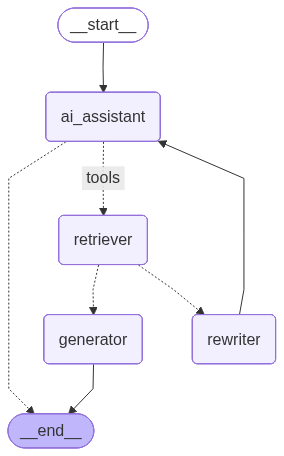

In [33]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    pass

Instead of printing the massive wall of JSON text, this uses the Python trick to get the clean answer.
response["messages"] grabs the conversation history.

[-1] grabs the very last message in the history (which is the final AI generated answer).


.content strips away the LangChain formatting and just prints the clean, human-readable text.

In [34]:
from langchain_core.messages import HumanMessage

response = app.invoke(
    {
        "messages": [
            HumanMessage(content="What is the exact birth date of Avneet Kaur?")
        ]
    }
)

---CALL AGENT---
---GENERATE---


In [35]:
print(response["messages"][-1].content)

Avneet Kaur was born on 13 October 2001. She was born in Jalandhar, Punjab, India, into a Sikh family. I do not have any additional information about her birth beyond this date and location.


create_react_agent: This is a massive shortcut function. When you give it your llm and your my_tools, it automatically builds the StateGraph, adds the nodes, writes the grade_documents routing logic, and wires up all the conditional edges perfectly behind the scenes. It gives you a flawless, crash-proof graph in one line of code.

In [36]:
# 1. Import the shortcut, web search, and ChatGroq
from langgraph.prebuilt import create_react_agent
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_groq import ChatGroq

# 2. Use the larger 70B model for better tool calling reliability
llm = ChatGroq(model_name="llama-3.3-70b-versatile")

# 3. Setup the Web Tool and combine it with your existing PDF tool
web_tool = DuckDuckGoSearchRun()
my_tools = [retriever_tool, web_tool]

# 4. Create the shortcut agent! (No modifier needed here)
shortcut_app = create_react_agent(llm, my_tools)

print("Agent is perfectly compiled and ready to use!")

Agent is perfectly compiled and ready to use!


C:\Users\rajku\AppData\Local\Temp\ipykernel_23184\1346010453.py:14: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  shortcut_app = create_react_agent(llm, my_tools)



This is how we enforce our "Guardrails".

Instead of importing HumanMessage, you can actually just pass a tuple: ("user", "my text"). 

LangGraph automatically understands this means a Human Message!

strict_rules + my_question: Before the question even reaches the AI, we use Python string addition (+) to glue your strict rules and your question together.
When the AI reads it, it sees: "You are a highly specialized AI... User Question: pm of india". The AI immediately realizes "pm of india" is not about Avneet Kaur, so it ignores the tools and refuses to answer!

In [38]:
# 1. Type your question here!
my_question = "avneet kaur shows"

# 2. We secretly attach the strict rules to your question!
strict_rules = """
You are a highly specialized AI assistant dedicated ONLY to answering questions about Avneet Kaur. 
If the user asks about ANY other topic, person, or subject, you must politely refuse to answer and remind them that you only talk about Avneet Kaur.
You must use your tools (PDF and Web Search) to gather accurate information about her.

User Question: """

# 3. The AI reads the rules AND the question together
response = shortcut_app.invoke({
    "messages": [
        ("user", strict_rules + my_question)
    ]
})

# 4. Print the answer nicely
print("\n🤖 AI Answer:")
print(response["messages"][-1].content)



🤖 AI Answer:
Avneet Kaur has appeared in numerous TV shows, including "Dance India Dance Li'l Masters" and "Jhalak Dikhhla Jaa". She has also acted in the TV series "Meri Maa" and "Aladdin - Naam Toh Suna Hoga". Additionally, Avneet has been a part of several music videos and has gained a large following on social media platforms.
